# Clustering para segmentar clientes de Ortopedia CEMYDI

**Técnica:** K-Means  
**Unidad de análisis:** un cliente resumido por su comportamiento histórico  
**Objetivo:** identificar segmentos según compras, rentas, interacciones, gasto e inactividad  
**Semilla:** 42

# 1. Comprensión del negocio

La segmentación permitirá identificar grupos de clientes con comportamientos similares y asignar una acción comercial diferente a cada segmento.

# 2. Comprensión de los datos

In [1]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
K_FINAL = 4
BATCH_NAME = "CEMYDI_DEMO_2024_2026_V1"
FECHA_CORTE = "2026-08-01"

In [2]:
# Carga del dataset
rutas_posibles = [
    Path("../05_Datasets/dataset_segmentacion_clientes.csv"),
    Path("05_Datasets/dataset_segmentacion_clientes.csv"),
    Path("dataset_segmentacion_clientes.csv"),
    Path("/content/dataset_segmentacion_clientes.csv")
]

ruta_dataset = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se encontró dataset_segmentacion_clientes.csv. "
        "Colócalo junto a la libreta o en la carpeta 05_Datasets."
    )

df = pd.read_csv(ruta_dataset)
df["last_activity"] = pd.to_datetime(df["last_activity"], errors="coerce")

print("Archivo utilizado:", ruta_dataset.resolve())
print("Dimensiones:", df.shape)
df.head()

Archivo utilizado: C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Clustering_CRISP_DM\dataset_segmentacion_clientes.csv
Dimensiones: (400, 20)


,customer_id,customer_name,email,views,searches,add_to_cart,favorites,shares,distinct_products_interacted,total_interactions,completed_sales,units_purchased,amount_spent_sales,valid_rentals,units_rented,amount_spent_rentals,average_rental_days,last_activity,days_since_last_activity,average_monthly_activity
0,1257,Alberto Hernán Guevara,demo.usuario001@cemydi.local,3,0,0,1,0,4,4,3,6,15888.90,1,1,2204.72,8.0,2025-11-23 13:21:00,251,0.25
1,1258,Angélica Nelly Lozada,demo.usuario002@cemydi.local,44,15,6,5,3,26,73,6,15,79178.37,0,0,0.00,0.0,2026-06-10 13:11:00,52,2.92
2,1259,Dolores Sanabria,demo.usuario003@cemydi.local,45,11,6,2,4,27,68,0,0,0.00,0,0,0.00,0.0,2026-04-17 10:51:00,106,22.67
3,1260,Celia María Acosta,demo.usuario004@cemydi.local,20,8,3,2,0,19,33,6,11,15662.89,0,0,0.00,0.0,2026-07-02 15:01:00,30,3.00
4,1261,Dolores Tirado,demo.usuario005@cemydi.local,23,7,3,2,2,20,37,3,5,18390.40,0,0,0.00,0.0,2026-06-23 11:42:00,39,1.85


In [3]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   customer_id                   400 non-null    int64         
 1   customer_name                 400 non-null    str           
 2   email                         400 non-null    str           
 3   views                         400 non-null    int64         
 4   searches                      400 non-null    int64         
 5   add_to_cart                   400 non-null    int64         
 6   favorites                     400 non-null    int64         
 7   shares                        400 non-null    int64         
 8   distinct_products_interacted  400 non-null    int64         
 9   total_interactions            400 non-null    int64         
 10  completed_sales               400 non-null    int64         
 11  units_purchased               400 non-null 

In [4]:
# Revisión de calidad
columnas_numericas = df.select_dtypes(include=np.number).columns

reporte_calidad = pd.DataFrame({
    "Revisión": [
        "Valores nulos",
        "Filas duplicadas",
        "Fechas inválidas",
        "Columnas constantes",
        "Valores negativos"
    ],
    "Resultado": [
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int(df["last_activity"].isna().sum()),
        [col for col in df.columns if df[col].nunique(dropna=False) <= 1],
        int((df[columnas_numericas] < 0).sum().sum())
    ]
})

reporte_calidad

,Revisión,Resultado
0,Valores nulos,0
1,Filas duplicadas,0
2,Fechas inválidas,0
3,Columnas constantes,[]
4,Valores negativos,0


In [5]:
# Estadísticas descriptivas
df.select_dtypes(include=np.number).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,400.0,1456.50,115.61,1257.00,1356.75,1456.50,1556.25,1656.00
views,400.0,29.75,13.61,0.00,20.00,29.00,41.00,63.00
searches,400.0,8.52,4.68,0.00,5.00,8.00,12.00,21.00
add_to_cart,400.0,4.63,2.87,0.00,2.00,4.00,6.00,14.00
favorites,400.0,2.45,1.84,0.00,1.00,2.00,3.00,10.00
shares,400.0,1.50,1.40,0.00,0.00,1.00,2.00,6.00
distinct_products_interacted,400.0,20.03,6.30,2.00,16.00,21.00,25.00,33.00
total_interactions,400.0,46.84,20.66,3.00,33.00,47.00,63.00,90.00
completed_sales,400.0,9.12,6.80,0.00,3.00,8.00,15.00,22.00
units_purchased,400.0,23.12,17.17,0.00,7.00,21.00,38.00,70.00


# 3. Preparación de los datos

In [6]:
# Variables utilizadas por K-Means
features = [
    "completed_sales",
    "valid_rentals",
    "amount_spent_sales",
    "amount_spent_rentals",
    "total_interactions",
    "distinct_products_interacted",
    "days_since_last_activity"
]

X = df[features].copy()

if X.isnull().any().any():
    raise ValueError("Las variables seleccionadas contienen valores nulos.")

if (X < 0).any().any():
    raise ValueError("Las variables seleccionadas contienen valores negativos.")

X.head()

,completed_sales,valid_rentals,amount_spent_sales,amount_spent_rentals,total_interactions,distinct_products_interacted,days_since_last_activity
0,3,1,15888.90,2204.72,4,4,251
1,6,0,79178.37,0.00,73,26,52
2,0,0,0.00,0.00,68,27,106
3,6,0,15662.89,0.00,33,19,30
4,3,0,18390.40,0.00,37,20,39


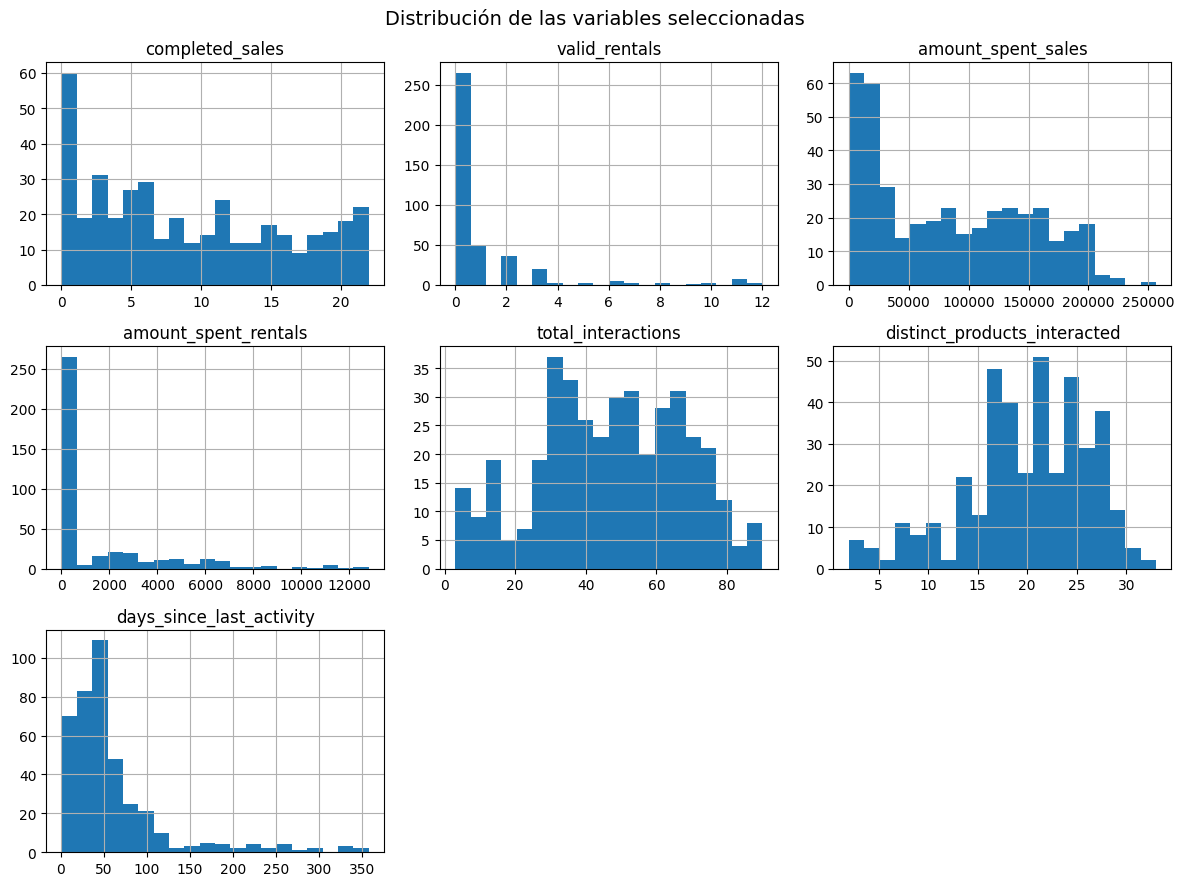

In [7]:
# Distribución de las variables seleccionadas
X.hist(figsize=(12, 9), bins=20)
plt.suptitle("Distribución de las variables seleccionadas", fontsize=14)
plt.tight_layout()
plt.show()

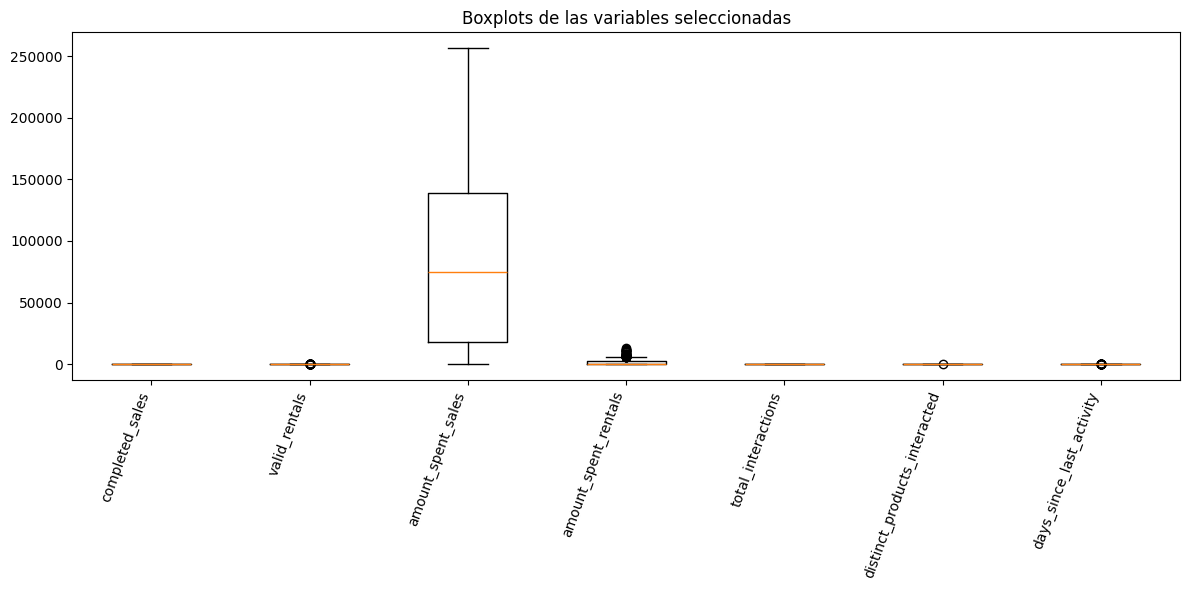

In [8]:
# Boxplots de las variables seleccionadas
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([X[columna] for columna in features], labels=features)
ax.set_xticklabels(features, rotation=70, ha="right")
ax.set_title("Boxplots de las variables seleccionadas")
plt.tight_layout()
plt.show()

In [9]:
# Transformación log1p y estandarización
X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

verificacion_escalado = pd.DataFrame({
    "Media": X_scaled.mean(axis=0),
    "Desviación estándar": X_scaled.std(axis=0)
}, index=features)

verificacion_escalado.round(4)

,Media,Desviación estándar
completed_sales,0.0,1.0
valid_rentals,0.0,1.0
amount_spent_sales,-0.0,1.0
amount_spent_rentals,0.0,1.0
total_interactions,0.0,1.0
distinct_products_interacted,-0.0,1.0
days_since_last_activity,0.0,1.0


# 4. Modelado

In [10]:
# Comparación de k = 2 a k = 8
resultados_k = []

for k in range(2, 9):
    modelo = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )
    etiquetas = modelo.fit_predict(X_scaled)

    resultados_k.append({
        "k": k,
        "Inercia": modelo.inertia_,
        "Silhouette": silhouette_score(X_scaled, etiquetas),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, etiquetas),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, etiquetas)
    })

metricas_k = pd.DataFrame(resultados_k)
metricas_k.round(4)

,k,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,1961.9708,0.4500,1.2091,170.0003
1,3,1329.9730,0.4109,1.0201,219.4032
2,4,979.1358,0.4496,0.8793,245.4757
3,5,849.6396,0.4268,0.9621,226.6821
4,6,750.2679,0.3213,1.0673,215.2816
5,7,677.7452,0.3266,1.0488,205.1032
6,8,623.0397,0.3201,1.0895,195.6694


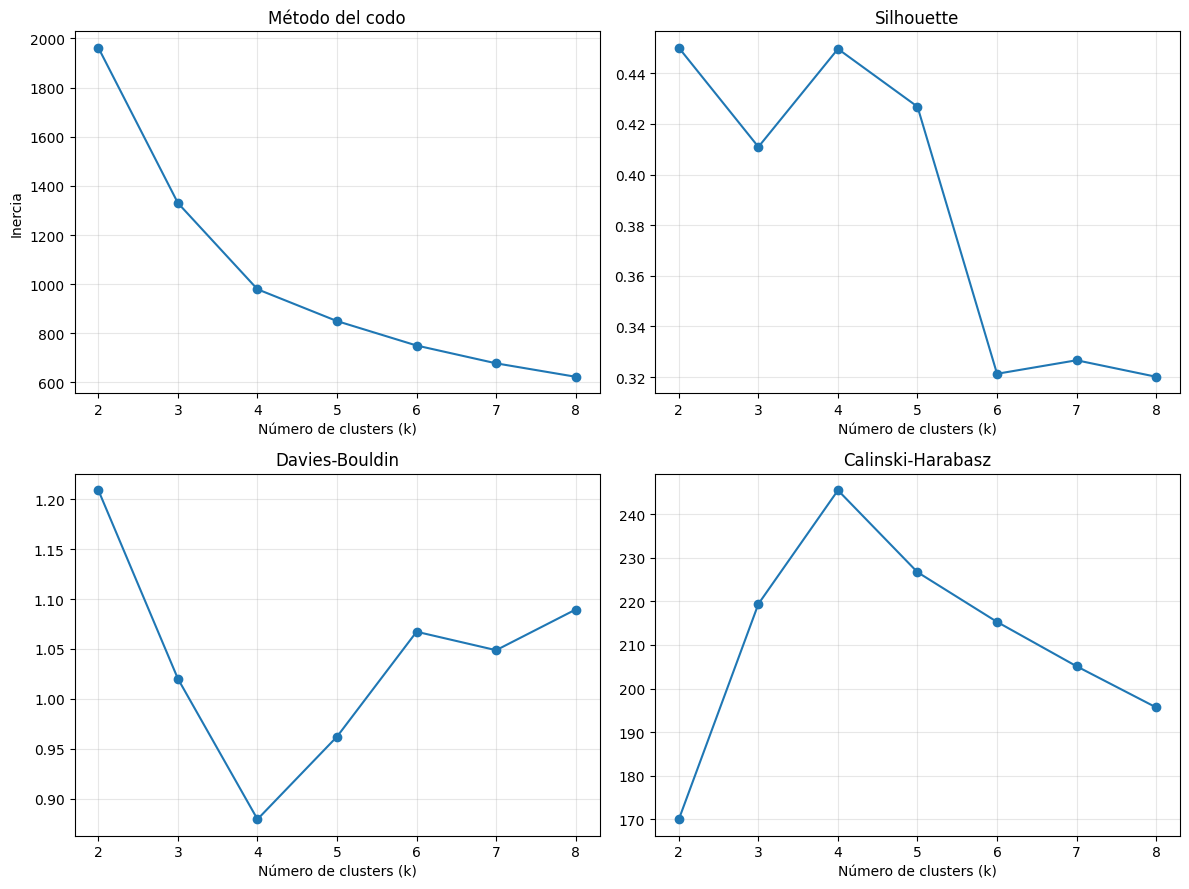

In [11]:
# Método del codo y métricas internas
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(metricas_k["k"], metricas_k["Inercia"], marker="o")
axes[0, 0].set_title("Método del codo")
axes[0, 0].set_ylabel("Inercia")

axes[0, 1].plot(metricas_k["k"], metricas_k["Silhouette"], marker="o")
axes[0, 1].set_title("Silhouette")

axes[1, 0].plot(metricas_k["k"], metricas_k["Davies-Bouldin"], marker="o")
axes[1, 0].set_title("Davies-Bouldin")

axes[1, 1].plot(metricas_k["k"], metricas_k["Calinski-Harabasz"], marker="o")
axes[1, 1].set_title("Calinski-Harabasz")

for ax in axes.flat:
    ax.set_xlabel("Número de clusters (k)")
    ax.set_xticks(metricas_k["k"])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

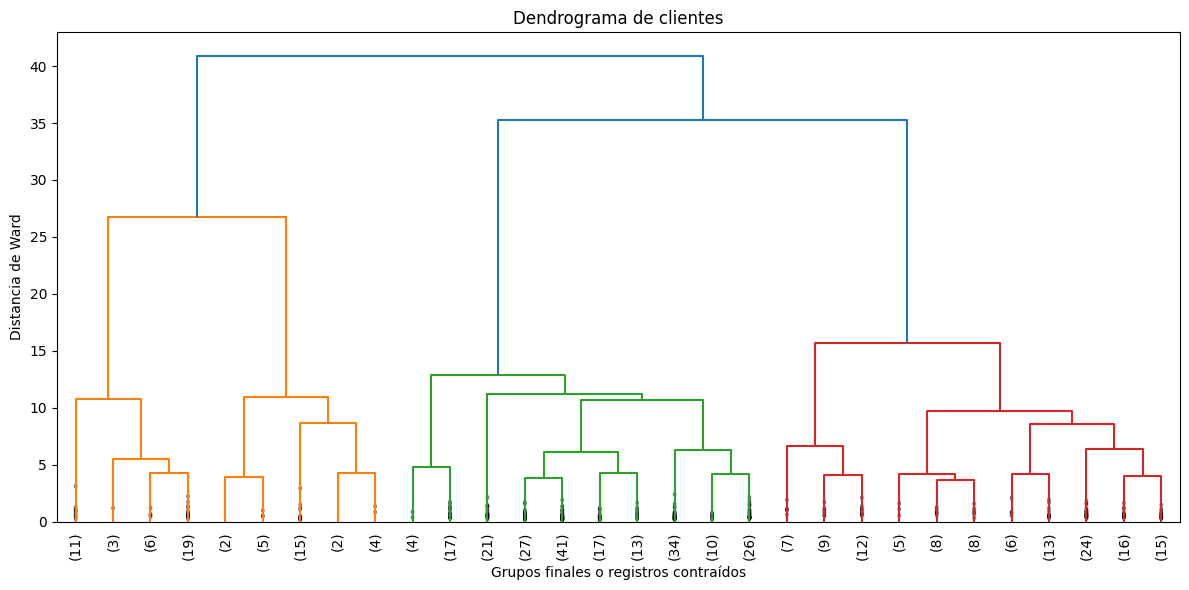

In [12]:
# Dendrograma de apoyo
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    show_contracted=True
)
plt.title("Dendrograma de clientes")
plt.xlabel("Grupos finales o registros contraídos")
plt.ylabel("Distancia de Ward")
plt.tight_layout()
plt.show()

In [13]:
# Modelo final con k = 4
modelo_final = KMeans(
    n_clusters=K_FINAL,
    n_init=20,
    random_state=RANDOM_STATE
)

df_resultado = df.copy()
df_resultado["cluster"] = modelo_final.fit_predict(X_scaled)

df_resultado["cluster"].value_counts().sort_index()

cluster
0     38
1    210
2    124
3     28
Name: count, dtype: int64

# 5. Evaluación

Se selecciona `k=4` considerando el método del codo, las métricas internas y la interpretación de los cuatro grupos.

In [14]:
# Métricas finales
metricas_finales = pd.DataFrame([{
    "k": K_FINAL,
    "Inercia": modelo_final.inertia_,
    "Silhouette": silhouette_score(X_scaled, df_resultado["cluster"]),
    "Davies-Bouldin": davies_bouldin_score(X_scaled, df_resultado["cluster"]),
    "Calinski-Harabasz": calinski_harabasz_score(
        X_scaled,
        df_resultado["cluster"]
    )
}])

metricas_finales.round(4)

,k,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,4,979.1358,0.4496,0.8793,245.4757


In [15]:
# Perfil promedio de cada cluster
perfil_clusters = (
    df_resultado.groupby("cluster")[features]
    .mean()
    .round(2)
)

perfil_clusters

,completed_sales,valid_rentals,amount_spent_sales,amount_spent_rentals,total_interactions,distinct_products_interacted,days_since_last_activity
cluster,,,,,,,
0,2.21,0.08,10763.44,197.44,9.68,7.47,196.21
1,11.11,0.00,105523.28,0.00,52.35,21.75,41.59
2,9.92,3.15,85229.84,4476.93,48.66,21.18,41.85
3,0.00,0.96,0.00,1315.01,47.93,19.11,94.36


In [16]:
# Asignación de nombres según el comportamiento dominante de cada cluster
clusters_disponibles = set(perfil_clusters.index)

cluster_baja = int(perfil_clusters["days_since_last_activity"].idxmax())
clusters_disponibles.remove(cluster_baja)

cluster_renta = int(
    perfil_clusters.loc[list(clusters_disponibles), "valid_rentals"].idxmax()
)
clusters_disponibles.remove(cluster_renta)

cluster_compra = int(
    perfil_clusters.loc[list(clusters_disponibles), "completed_sales"].idxmax()
)
clusters_disponibles.remove(cluster_compra)

cluster_explorador = int(next(iter(clusters_disponibles)))

nombres_segmentos = {
    cluster_compra: "Compradores frecuentes",
    cluster_renta: "Arrendatarios recurrentes",
    cluster_explorador: "Exploradores",
    cluster_baja: "Baja actividad"
}

interpretaciones = {
    cluster_compra: "Compras recurrentes y mayor gasto acumulado en ventas.",
    cluster_renta: "Mayor uso y gasto acumulado en el servicio de renta.",
    cluster_explorador: "Interacción con productos, pero poca conversión en compras.",
    cluster_baja: "Pocas interacciones y mayor tiempo desde la última actividad."
}

acciones = {
    cluster_compra: "Ofrecer beneficios de fidelización y recompra.",
    cluster_renta: "Ofrecer renovaciones, mantenimiento y renta extendida.",
    cluster_explorador: "Enviar recordatorios y ofrecer asesoría de compra.",
    cluster_baja: "Aplicar campañas de reactivación y seguimiento."
}

df_resultado["segmento"] = df_resultado["cluster"].map(nombres_segmentos)
df_resultado["accion_sugerida"] = df_resultado["cluster"].map(acciones)

orden_segmentos = [
    "Compradores frecuentes",
    "Arrendatarios recurrentes",
    "Exploradores",
    "Baja actividad"
]

resumen_segmentos = (
    df_resultado.groupby(["cluster", "segmento"])[features]
    .mean()
    .round(2)
)

conteos = df_resultado.groupby(["cluster", "segmento"]).size()
porcentajes = conteos.div(len(df_resultado)).mul(100).round(2)

resumen_segmentos.insert(0, "Clientes", conteos)
resumen_segmentos.insert(1, "Porcentaje", porcentajes)

resumen_segmentos.reset_index().sort_values(
    "segmento",
    key=lambda serie: pd.Categorical(serie, categories=orden_segmentos, ordered=True)
)

,cluster,segmento,Clientes,Porcentaje,completed_sales,valid_rentals,amount_spent_sales,amount_spent_rentals,total_interactions,distinct_products_interacted,days_since_last_activity
1,1,Compradores frecuentes,210,52.5,11.11,0.00,105523.28,0.00,52.35,21.75,41.59
2,2,Arrendatarios recurrentes,124,31.0,9.92,3.15,85229.84,4476.93,48.66,21.18,41.85
3,3,Exploradores,28,7.0,0.00,0.96,0.00,1315.01,47.93,19.11,94.36
0,0,Baja actividad,38,9.5,2.21,0.08,10763.44,197.44,9.68,7.47,196.21


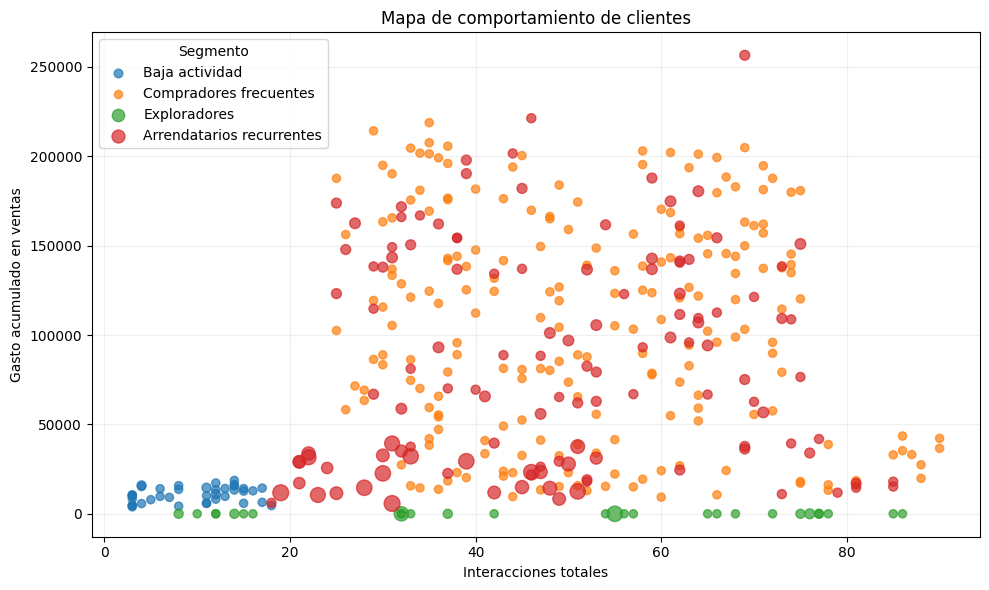

In [17]:
# Mapa de comportamiento de clientes
fig, ax = plt.subplots(figsize=(10, 6))

for segmento in df_resultado["segmento"].unique():
    datos = df_resultado[df_resultado["segmento"] == segmento]
    ax.scatter(
        datos["total_interactions"],
        datos["amount_spent_sales"],
        label=segmento,
        alpha=0.70,
        s=35 + datos["valid_rentals"] * 8
    )

ax.set_title("Mapa de comportamiento de clientes")
ax.set_xlabel("Interacciones totales")
ax.set_ylabel("Gasto acumulado en ventas")
ax.legend(title="Segmento")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

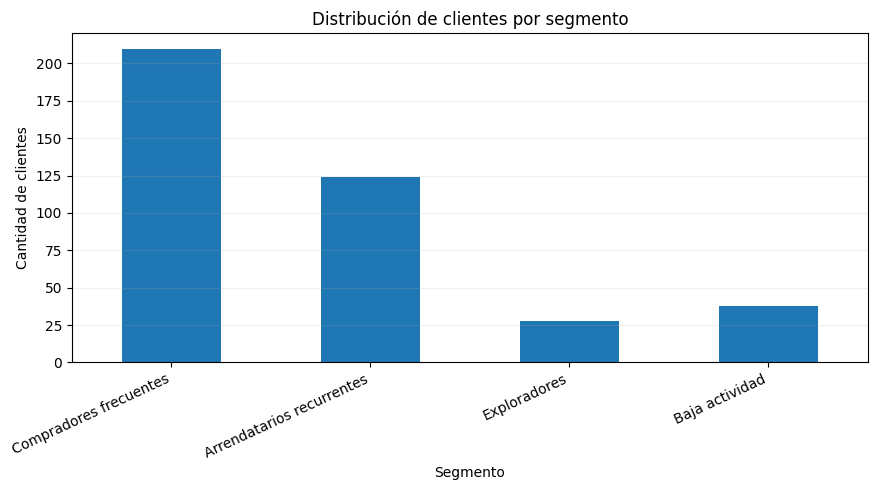

In [18]:
# Distribución de clientes por segmento
distribucion_segmentos = (
    df_resultado["segmento"]
    .value_counts()
    .reindex(orden_segmentos)
)

fig, ax = plt.subplots(figsize=(9, 5))
distribucion_segmentos.plot(kind="bar", ax=ax)
ax.set_title("Distribución de clientes por segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Cantidad de clientes")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

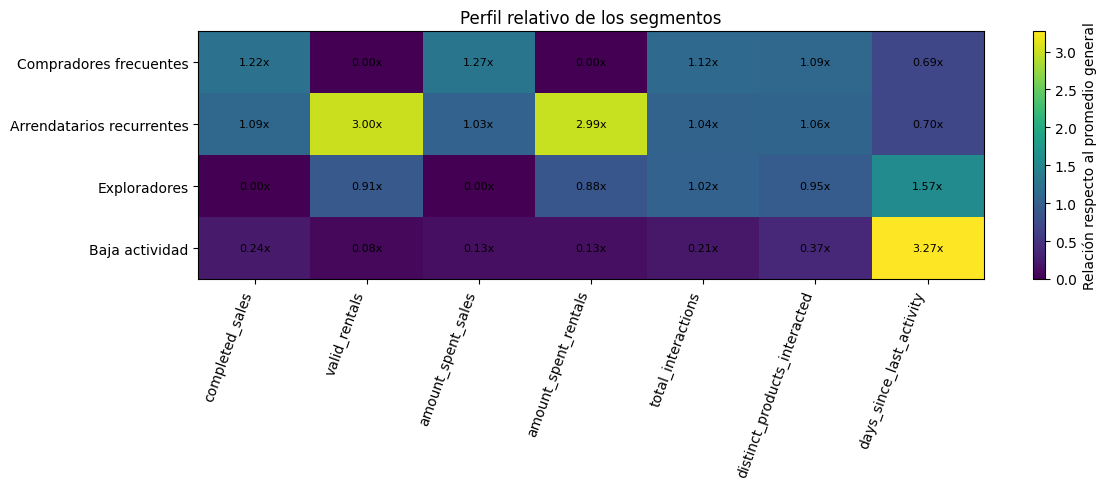

In [19]:
# Perfil relativo respecto al promedio general
promedio_general = df_resultado[features].mean()

perfil_relativo = perfil_clusters.div(promedio_general, axis=1)
perfil_relativo.index = perfil_relativo.index.map(nombres_segmentos)
perfil_relativo = perfil_relativo.reindex(orden_segmentos)

fig, ax = plt.subplots(figsize=(12, 5))
imagen = ax.imshow(perfil_relativo, aspect="auto")

ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=70, ha="right")
ax.set_yticks(range(len(perfil_relativo.index)))
ax.set_yticklabels(perfil_relativo.index)
ax.set_title("Perfil relativo de los segmentos")

for fila in range(perfil_relativo.shape[0]):
    for columna in range(perfil_relativo.shape[1]):
        ax.text(
            columna,
            fila,
            f"{perfil_relativo.iloc[fila, columna]:.2f}x",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(imagen, ax=ax, label="Relación respecto al promedio general")
plt.tight_layout()
plt.show()

In [20]:
# Dos clientes por segmento
columnas_mostrar = [
    "customer_id",
    "customer_name",
    "email",
    "segmento",
    "completed_sales",
    "valid_rentals",
    "amount_spent_sales",
    "amount_spent_rentals",
    "total_interactions",
    "days_since_last_activity",
    "accion_sugerida"
]

casos_por_segmento = (
    df_resultado[columnas_mostrar]
    .groupby("segmento", group_keys=False)
    .head(2)
    .assign(
        segmento=lambda tabla: pd.Categorical(
            tabla["segmento"],
            categories=orden_segmentos,
            ordered=True
        )
    )
    .sort_values(["segmento", "customer_id"])
    .reset_index(drop=True)
)

casos_por_segmento

,customer_id,customer_name,email,segmento,completed_sales,valid_rentals,amount_spent_sales,amount_spent_rentals,total_interactions,days_since_last_activity,accion_sugerida
0,1258,Angélica Nelly Lozada,demo.usuario002@cemydi.local,Compradores frecuentes,6,0,79178.37,0.00,73,52,Ofrecer beneficios de fidelización y recompra.
1,1260,Celia María Acosta,demo.usuario004@cemydi.local,Compradores frecuentes,6,0,15662.89,0.00,33,30,Ofrecer beneficios de fidelización y recompra.
2,1263,Emilio Ojeda Acevedo,demo.usuario007@cemydi.local,Arrendatarios recurrentes,5,2,256472.58,1722.17,69,51,"Ofrecer renovaciones, mantenimiento y renta ex..."
3,1273,Alicia Saldaña Meléndez,demo.usuario017@cemydi.local,Arrendatarios recurrentes,16,2,82536.76,5915.32,52,53,"Ofrecer renovaciones, mantenimiento y renta ex..."
4,1259,Dolores Sanabria,demo.usuario003@cemydi.local,Exploradores,0,0,0.00,0.00,68,106,Enviar recordatorios y ofrecer asesoría de com...
5,1267,Claudio Ibarra Domínguez,demo.usuario011@cemydi.local,Exploradores,0,0,0.00,0.00,77,75,Enviar recordatorios y ofrecer asesoría de com...
6,1257,Alberto Hernán Guevara,demo.usuario001@cemydi.local,Baja actividad,3,1,15888.90,2204.72,4,251,Aplicar campañas de reactivación y seguimiento.
7,1270,Luis Manuel Lucas Menéndez,demo.usuario014@cemydi.local,Baja actividad,3,0,4595.47,0.00,18,204,Aplicar campañas de reactivación y seguimiento.


# 6. Despliegue

In [21]:
# Pipeline final y generación de artefactos
pipeline_final = Pipeline([
    (
        "seleccion",
        ColumnTransformer(
            transformers=[("variables", "passthrough", features)],
            remainder="drop",
            verbose_feature_names_out=False
        )
    ),
    (
        "log1p",
        FunctionTransformer(
            np.log1p,
            validate=False,
            feature_names_out="one-to-one"
        )
    ),
    ("escalado", StandardScaler()),
    (
        "kmeans",
        KMeans(
            n_clusters=K_FINAL,
            n_init=20,
            random_state=RANDOM_STATE
        )
    )
])

pipeline_final.fit(df)

# Verificar que el pipeline reproduce las etiquetas del modelo evaluado
etiquetas_pipeline = pipeline_final.predict(df)
coincidencia_total = bool(
    np.array_equal(etiquetas_pipeline, df_resultado["cluster"].to_numpy())
)

if not coincidencia_total:
    raise RuntimeError(
        "El pipeline final no reproduce las etiquetas evaluadas."
    )

directorio_actual = Path.cwd()

if directorio_actual.name == "06_Notebooks":
    raiz_proyecto = directorio_actual.parent
elif (directorio_actual / "05_Datasets").exists():
    raiz_proyecto = directorio_actual
else:
    raiz_proyecto = directorio_actual

carpeta_modelos = raiz_proyecto / "07_Modelos" / "clustering"
carpeta_modelos.mkdir(parents=True, exist_ok=True)

ruta_pipeline = carpeta_modelos / "clustering_clientes_pipeline.joblib"
ruta_clientes = carpeta_modelos / "clientes_segmentados.csv"
ruta_perfiles = carpeta_modelos / "perfiles_segmentos.json"
ruta_metadata = carpeta_modelos / "metadata_clustering.json"

joblib.dump(pipeline_final, ruta_pipeline)

df_resultado.to_csv(
    ruta_clientes,
    index=False,
    encoding="utf-8"
)

perfiles_json = {
    str(cluster): {
        "segmento": nombres_segmentos[cluster],
        "interpretacion": interpretaciones[cluster],
        "accion_sugerida": acciones[cluster],
        "perfil_promedio": {
            variable: float(perfil_clusters.loc[cluster, variable])
            for variable in features
        }
    }
    for cluster in sorted(nombres_segmentos)
}

ruta_perfiles.write_text(
    json.dumps(perfiles_json, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

modelo_pipeline = pipeline_final.named_steps["kmeans"]

metadata_clustering = {
    "solucion": "Segmentación de clientes de CEMYDI",
    "batch_name": BATCH_NAME,
    "fecha_corte": FECHA_CORTE,
    "fecha_entrenamiento": datetime.now().isoformat(timespec="seconds"),
    "dataset": ruta_dataset.name,
    "datos": "100 % sintéticos",
    "unidad_analisis": "Un cliente",
    "registros": int(len(df)),
    "variables": features,
    "transformaciones": ["log1p", "StandardScaler"],
    "algoritmo": "KMeans",
    "parametros": {
        "k": K_FINAL,
        "n_init": 20,
        "random_state": RANDOM_STATE
    },
    "metricas": {
        "inercia": float(metricas_finales.loc[0, "Inercia"]),
        "silhouette": float(metricas_finales.loc[0, "Silhouette"]),
        "davies_bouldin": float(
            metricas_finales.loc[0, "Davies-Bouldin"]
        ),
        "calinski_harabasz": float(
            metricas_finales.loc[0, "Calinski-Harabasz"]
        )
    },
    "centroides_escalados": modelo_pipeline.cluster_centers_.tolist(),
    "segmentos": {
        str(cluster): nombres_segmentos[cluster]
        for cluster in sorted(nombres_segmentos)
    }
}

ruta_metadata.write_text(
    json.dumps(metadata_clustering, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("Coincidencia del pipeline con el modelo evaluado:", coincidencia_total)
print("Archivos generados:")
print("-", ruta_pipeline)
print("-", ruta_clientes)
print("-", ruta_perfiles)
print("-", ruta_metadata)

Coincidencia del pipeline con el modelo evaluado: True
Archivos generados:
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Clustering_CRISP_DM\07_Modelos\clustering\clustering_clientes_pipeline.joblib
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Clustering_CRISP_DM\07_Modelos\clustering\clientes_segmentados.csv
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Clustering_CRISP_DM\07_Modelos\clustering\perfiles_segmentos.json
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Clustering_CRISP_DM\07_Modelos\clustering\metadata_clustering.json


In [22]:
# Carga del pipeline y prueba con un cliente nuevo ficticio
pipeline_cargado = joblib.load(ruta_pipeline)

nuevo_cliente = pd.DataFrame([{
    "completed_sales": 4,
    "valid_rentals": 0,
    "amount_spent_sales": 18500.00,
    "amount_spent_rentals": 0.00,
    "total_interactions": 35,
    "distinct_products_interacted": 16,
    "days_since_last_activity": 25
}])

cluster_nuevo = int(pipeline_cargado.predict(nuevo_cliente)[0])

pd.DataFrame([{
    "cluster_predicho": cluster_nuevo,
    "segmento": nombres_segmentos[cluster_nuevo],
    "accion_sugerida": acciones[cluster_nuevo]
}])

,cluster_predicho,segmento,accion_sugerida
0,1,Compradores frecuentes,Ofrecer beneficios de fidelización y recompra.


# Conclusión breve

K-Means con `k=4` identificó cuatro segmentos interpretables: compradores frecuentes, arrendatarios recurrentes, exploradores y clientes de baja actividad. El pipeline final conserva la selección de variables, la transformación `log1p`, el escalado y el modelo.